# Working with complicated dataset

Your name: Yeqing Xu

### Question 1

blast_results: https://raw.githubusercontent.com/csbfx/advpy122-data/master/blast_results.csv

Read in the data from the csv file above. Skip all the comment lines, create a header for the dataframe based on the fields list in the comment line that starts with **# Fields:**. Drop the first column `query acc.ver`. Set the `subject acc.ver` as the index of the dataframe. The last column of the dataframe should be `publications`. Show the first five rows of the resulting dataframe.

In [55]:
### Your code here . . .
import pandas as pd
file = 'https://raw.githubusercontent.com/csbfx/advpy122-data/master/blast_results.csv'

In [56]:
import urllib.request
with urllib.request.urlopen(file) as response:
    for i in range(15):
        line = response.readline().decode('utf-8').strip()
        print(f"{i + 1}: {line}")

1: # blastp,,,,,,,,,,,,,,,
2: # Iteration: 0,,,,,,,,,,,,,,,
3: # Query: YP_220550.1 NADH dehydrogenase subunit 1 (mitochondrion) [Mus musculus domesticus],,,,,,,,,,,,,,,
4: # RID: 9SW3UNUT015,,,,,,,,,,,,,,,
5: # Database: nr,,,,,,,,,,,,,,,
6: "# Fields: query acc.ver, subject acc.ver, % identity, alignment length, mismatches, gap opens, q. start, q. end, s. start, s. end, evalue, bit score, % positives, bonds, publications",,,,,,,,,,,,,,,
7: # 100 hits found,,,,,,,,,,,,,,,
8: YP_220550.1,NP_904328.1,100,318,0,0,1,318,1,318,0,629,100," 1,487 ",9,
9: YP_220550.1,AGK29621.1,99.686,318,1,0,1,318,1,318,0,629,100," 17,947 ",47,
10: YP_220550.1,YP_220563.1,99.686,318,1,0,1,318,1,318,0,627,100," 12,106 ",13,
11: YP_220550.1,ACM24502.1,99.686,318,1,0,1,318,1,318,0,627,99.69," 2,319 ",41,
12: YP_220550.1,AHG32084.1,99.371,318,2,0,1,318,1,318,0,627,100," 18,964 ",3,
13: YP_220550.1,AEN03421.1,99.686,318,1,0,1,318,1,318,0,626,99.69," 12,444 ",39,
14: YP_220550.1,6G2J_H,100,317,0,0,2,318,2,318,0,62

In [57]:
full_column_names = ["query acc.ver", "subject acc.ver", "% identity", "alignment length", "mismatches",
                "gap opens", "q. start", "q. end", "s. start", "s. end", "evalue",
                "bit score", "% positives", "bonds", "publications"]

df = pd.read_csv(file,
                 na_values=['-'],
                 skiprows=7, #skips comment lines including the header line itself
                 header=None, #no header in the CSV file
                 names=full_column_names, #set the column names
                 usecols=full_column_names,
                 index_col='subject acc.ver', #set the index to 'subject acc.ver'
                 )

df.drop(columns='query acc.ver', inplace=True) #drop the first column by name
# dp.set_index('subject acc.ver', inplace=True) #set the index to 'subject acc.ver'
df.head()

,% identity,alignment length,mismatches,gap opens,q. start,q. end,s. start,s. end,evalue,bit score,% positives,bonds,publications
subject acc.ver,,,,,,,,,,,,,
NP_904328.1,100.000,318,0,0,1,318,1,318,0,629,100.00,"1,487",9.0
AGK29621.1,99.686,318,1,0,1,318,1,318,0,629,100.00,"17,947",47.0
YP_220563.1,99.686,318,1,0,1,318,1,318,0,627,100.00,"12,106",13.0
ACM24502.1,99.686,318,1,0,1,318,1,318,0,627,99.69,"2,319",41.0
AHG32084.1,99.371,318,2,0,1,318,1,318,0,627,100.00,"18,964",3.0


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100 entries, NP_904328.1 to AGS12808.1
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   % identity        100 non-null    float64
 1   alignment length  100 non-null    int64  
 2   mismatches        100 non-null    int64  
 3   gap opens         100 non-null    int64  
 4   q. start          100 non-null    int64  
 5   q. end            100 non-null    int64  
 6   s. start          100 non-null    int64  
 7   s. end            100 non-null    int64  
 8   evalue            100 non-null    int64  
 9   bit score         100 non-null    int64  
 10  % positives       100 non-null    float64
 11  bonds             100 non-null    object 
 12  publications      97 non-null     float64
dtypes: float64(3), int64(9), object(1)
memory usage: 10.9+ KB


### Question 2
What is the average number of publications?

In [59]:
### Your code here . . .
print("Average number of Publications: " + str(df['publications'].mean()))

Average number of Publications: 26.989690721649485


### Question 3
List the `subject acc.ver` that has over 15,000 bonds.

In [60]:
### Your code here . . .
print(df["bonds"].dtype)
import re
all_bonds = df["bonds"].dropna().unique()
non_numeric_bonds = [i for i in all_bonds if not re.match(r'^\d+$', str(i))]
print(non_numeric_bonds)

object
[' 1,487 ', ' 17,947 ', ' 12,106 ', ' 2,319 ', ' 18,964 ', ' 12,444 ', ' 15,663 ', ' 14,478 ', ' 8,022 ', ' 4,355 ', ' 4,613 ', ' 3,614 ', ' 15,830 ', ' 6,558 ', ' 5,839 ', ' 12,152 ', ' 7,859 ', ' 17,381 ', ' 17,499 ', ' 10,445 ', ' 14,317 ', ' 16,861 ', ' 16,274 ', ' 5,815 ', ' 16,170 ', ' 19,706 ', ' 15,023 ', ' 18,777 ', ' 9,579 ', ' 1,618 ', ' 17,739 ', ' 17,523 ', ' 15,963 ', ' 6,148 ', ' 4,181 ', ' 2,253 ', ' 9,003 ', ' 14,360 ', ' 4,746 ', ' 13,230 ', ' 16,017 ', ' 4,966 ', ' 18,973 ', ' 8,417 ', ' 18,196 ', ' 10,577 ', ' 16,113 ', ' 13,444 ', ' 9,657 ', ' 6,836 ', ' 15,809 ', ' 13,033 ', ' 19,998 ', ' 13,009 ', ' 1,347 ', ' 9,016 ', ' 7,660 ', ' 1,019 ', ' 19,932 ', ' 14,591 ', ' 5,474 ', ' 8,209 ', ' 19,814 ', ' 18,372 ', ' 18,573 ', ' 1,852 ', ' 14,703 ', ' 4,647 ', ' 16,721 ', ' 13,856 ', ' 2,278 ', ' 8,374 ', ' 17,627 ', ' 10,904 ', ' 3,809 ', ' 9,391 ', ' 2,544 ', ' 11,512 ', ' 2,978 ', ' 6,808 ', ' 2,857 ', ' 6,409 ', ' 19,875 ', ' 10,226 ', ' 18,207 ', ' 15,913 '

In [61]:
# Remove commas
df['bonds'] = df['bonds'].str.replace(',', '')

# Convert the cleaned column to a numeric data type
df['bonds'] = pd.to_numeric(dp['bonds'], errors='coerce')

print(df['bonds'].dtype)

int64


In [62]:
filtered_df = df[df['bonds'] > 15000]
print(filtered_df.index.tolist())

['AGK29621.1', 'AHG32084.1', '6G2J_H', 'YP_002791042.1', 'AGK29634.1', '0806162F', 'YP_009112408.1', 'YP_001876469.1', 'YP_009092269.1', 'AHG32149.1', 'YP_009092074.1', 'YP_009450474.1', 'YP_004123270.1', 'YP_009092073.1', 'AHZ60901.1', 'YP_004123350.1', 'YP_009453754.1', 'ADD46492.1', 'YP_007025968.1', 'YP_009453806.1', 'YP_007024956.1', 'ASM92364.1', 'YP_006073044.1', 'ASM92494.1', 'ADG95699.1', 'YP_004891275.1', 'YP_009166014.1', 'YP_009538416.1', 'YP_009414182.1', 'YP_009178854.1', 'YP_009414415.1', 'YP_009353908.1', 'YP_009093743.1', 'ABX45285.1', 'YP_009414156.1', 'YP_009414363.1']


### Question 4
Create a plot that shows the correlation between `% identity` and `% positives`.

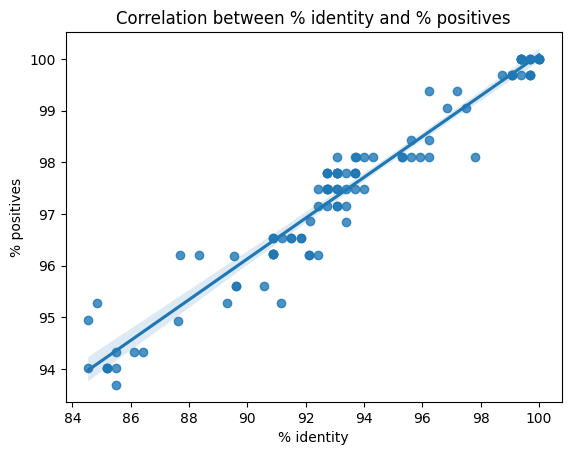

In [63]:
### Your code here . . .
import seaborn as sns
import matplotlib.pyplot as plt
sns.regplot(
    data = df,
    x = '% identity',
    y = '% positives'
    )
plt.title('Correlation between % identity and % positives')
plt.show()

### Question  5
Add a column `Protein source` to the dataframe from Question 1 based on the data in this csv file: https://raw.githubusercontent.com/csbfx/advpy122-data/master/protein_source.csv. Merge the data when the `subject acc.ver` from the dataframe equals to `Protein` in the csv file. Entries without a matching protein will have `NA` as `Protein source`.

In [66]:
### Your code here . . .
url_ps = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/protein_source.csv"
protein_df = pd.read_csv(url_ps)
df_reset = df.reset_index() # reset the index to a regular column
merged_df = df_reset.merge(
    protein_df,
    left_on='subject acc.ver',
    right_on='Protein',
    how = 'left'
    )
merged_df = merged_df.set_index('subject acc.ver')
merged_df = merged_df.rename(columns={'Source': 'Protein source'})
merged_df = merged_df.drop(columns=['Protein', 'Unnamed: 0'])
merged_df.head()


,% identity,alignment length,mismatches,gap opens,q. start,q. end,s. start,s. end,evalue,bit score,% positives,bonds,publications,Protein source
subject acc.ver,,,,,,,,,,,,,,
NP_904328.1,100.000,318,0,0,1,318,1,318,0,629,100.00,1487,9.0,RefSeq
AGK29621.1,99.686,318,1,0,1,318,1,318,0,629,100.00,17947,47.0,NaN
YP_220563.1,99.686,318,1,0,1,318,1,318,0,627,100.00,12106,13.0,GenPept
ACM24502.1,99.686,318,1,0,1,318,1,318,0,627,99.69,2319,41.0,NaN
AHG32084.1,99.371,318,2,0,1,318,1,318,0,627,100.00,18964,3.0,NaN
